<a href="https://colab.research.google.com/github/Hiraz-cipher/D-B-Assignment/blob/main/Python_data_processing_(Part_3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries ready")

Libraries ready


Load ALL files

In [4]:
customers  = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/customers.csv")
orders     = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/orders.csv")
deliveries = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/deliveries.csv")
complaints = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/complaints.csv")
drivers    = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/drivers.csv")
vehicles   = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/vehicles.csv")
hubs       = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/hubs.csv")
incidents  = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/incidents.csv")
app_events = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/app_events.csv" )

for name, df in [('customers',customers),('orders',orders),
                 ('deliveries',deliveries),('complaints',complaints),
                 ('drivers',drivers),('vehicles',vehicles),
                 ('hubs',hubs),('incidents',incidents),('app_events',app_events)]:
    print(f"{name}: {len(df)} rows, {len(df.columns)} columns")

customers: 650 rows, 9 columns
orders: 1250 rows, 11 columns
deliveries: 950 rows, 13 columns
complaints: 320 rows, 10 columns
drivers: 170 rows, 8 columns
vehicles: 120 rows, 8 columns
hubs: 8 rows, 5 columns
incidents: 280 rows, 7 columns
app_events: 640 rows, 10 columns


Clean the data

In [5]:
def clean_zone(value):

    if pd.isna(value):
        return value
    value = str(value).strip().upper()   # PDF string methods
    if value == 'CTR':
        value = 'CENTRAL'
    return value

# Apply to every zone column across all files
customers['home_zone']       = customers['home_zone'].apply(clean_zone)
orders['pickup_zone']        = orders['pickup_zone'].apply(clean_zone)
orders['dropoff_zone']       = orders['dropoff_zone'].apply(clean_zone)
drivers['base_zone']         = drivers['base_zone'].apply(clean_zone)
vehicles['assigned_zone']    = vehicles['assigned_zone'].apply(clean_zone)
hubs['zone']                 = hubs['zone'].apply(clean_zone)
app_events['zone_context']   = app_events['zone_context'].apply(clean_zone)

print("Zones cleaned. Unique zones in orders pickup_zone:")
print(sorted(orders['pickup_zone'].dropna().unique()))


Zones cleaned. Unique zones in orders pickup_zone:
['AIRPORT', 'CENTRAL', 'EAST', 'NORTH', 'RIVERSIDE', 'SOUTH', 'WEST']


Missing values across ALL files

In [7]:
print("=== MISSING VALUES IN ALL 9 FILES ===\n")

# Dictionary of all files — PDF Section 2.1.3
all_files = {
    'customers': customers, 'orders': orders,
    'deliveries': deliveries, 'complaints': complaints,
    'drivers': drivers, 'vehicles': vehicles,
    'hubs': hubs, 'incidents': incidents, 'app_events': app_events
}

# Loop using .items()
for name, df in all_files.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"{name}.csv:")
        for col, cnt in missing.items():
            pct = round(100 * cnt / len(df), 1)
            print(f"  {col}: {cnt} missing ({pct}%)")
        print()
    else:
        print(f"{name}.csv: No missing values")

# fillna() — replace NaN with a fixed value
customers['loyalty_score'].fillna(
    customers['loyalty_score'].median(), inplace=True)
drivers['training_score'].fillna(
    drivers['training_score'].median(), inplace=True)
vehicles['battery_health_pct'].fillna(
    vehicles['battery_health_pct'].median(), inplace=True)
complaints['compensation_amount'].fillna(0, inplace=True)
incidents['resolved_hours'].fillna(
    incidents['resolved_hours'].median(), inplace=True)
orders['booking_channel'].fillna('Unknown', inplace=True)

# ffill() — forward-fill sequential records
deliveries['customer_rating_post_delivery'] = \
    deliveries['customer_rating_post_delivery'].ffill()

print("Missing values handled using fillna() and ffill().")

=== MISSING VALUES IN ALL 9 FILES ===

customers.csv:
  preferred_channel: 13 missing (2.0%)

orders.csv: No missing values
deliveries.csv:
  delivery_completed_at: 19 missing (2.0%)

complaints.csv: No missing values
drivers.csv: No missing values
vehicles.csv: No missing values
hubs.csv: No missing values
incidents.csv: No missing values
app_events.csv:
  order_id: 144 missing (22.5%)

Missing values handled using fillna() and ffill().


/tmp/ipykernel_582/1074714899.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers['loyalty_score'].fillna(
/tmp/ipykernel_582/1074714899.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.meth

Chart 1 — Full delivery (deliveries + orders + hubs)

In [9]:
# Merge deliveries with orders and hubs
del_full = deliveries.merge(
    orders[['order_id', 'service_type', 'pickup_zone',
            'order_value', 'priority_level']],
    on='order_id', how='left'
).merge(
    hubs[['hub_id', 'hub_name', 'zone', 'hub_type', 'capacity_score']],
    on='hub_id', how='left'
)

# Summary by service type
print("=== DELIVERY OUTCOME BY SERVICE TYPE ===")
service_summary = del_full.groupby('service_type')['delivery_status']\
    .value_counts(normalize=True).mul(100).round(1).unstack(fill_value=0)
print(service_summary)

# Hub performance summary
print("\n=== DELIVERY FAILURE RATE BY HUB ===")
hub_perf = del_full.groupby('hub_name').agg(
    total=('delivery_id', 'count'),
    failed=('delivery_status', lambda x: (x == 'Failed').sum()),
    avg_rating=('customer_rating_post_delivery', 'mean')
).round(2)
hub_perf['fail_pct'] = \
    (hub_perf['failed'] / hub_perf['total'] * 100).round(1)
print(hub_perf.sort_values('fail_pct', ascending=False))

=== DELIVERY OUTCOME BY SERVICE TYPE ===
delivery_status  Delayed  Failed  OnTime
service_type                            
Business            22.2    19.8    57.9
Medical             20.4    14.8    64.8
Parcel              21.3    10.9    67.8
Passenger           20.2    14.5    65.3
Retail              22.3    12.5    65.2

=== DELIVERY FAILURE RATE BY HUB ===
                total  failed  avg_rating  fail_pct
hub_name                                           
Midtown Relay     128      26        3.89      20.3
Central Core      115      23        3.69      20.0
Airport Hub       104      15        3.88      14.4
West Gate         127      16        3.92      12.6
North Exchange    136      17        3.84      12.5
Riverside Hub     115      14        3.90      12.2
South Link        106      10        3.95       9.4
East Dock         119      11        3.91       9.2


Chart 2: Delivery outcomes by service type

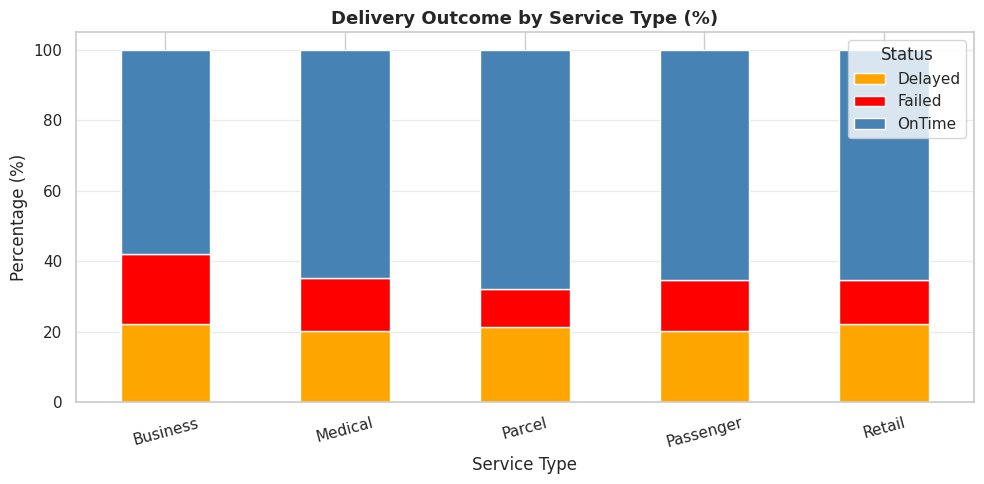

delivery_status  Delayed  Failed  OnTime
service_type                            
Business            22.2    19.8    57.9
Medical             20.4    14.8    64.8
Parcel              21.3    10.9    67.8
Passenger           20.2    14.5    65.3
Retail              22.3    12.5    65.2

Source: deliveries.csv merged with orders.csv


In [10]:

service_counts = del_full.groupby(
    ['service_type', 'delivery_status']).size().unstack(fill_value=0)
service_pct = service_counts.div(
    service_counts.sum(axis=1), axis=0) * 100

service_pct.plot(
    kind='bar', stacked=True,
    color={'Failed': 'red', 'Delayed': 'orange', 'OnTime': 'steelblue'},
    figsize=(10, 5)
)

# PDF Section 7 — xlabel, ylabel, title, xticks, legend
plt.title('Delivery Outcome by Service Type (%)',
          fontsize=13, fontweight='bold')
plt.xlabel('Service Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)     #  plt.xticks()
plt.legend(title='Status')
plt.grid(True, axis='y', alpha=0.4)   # plt.grid(True)
plt.tight_layout()
plt.savefig('chart1_service_outcomes.png')
plt.show()

print(service_pct.round(1))
print("\nSource: deliveries.csv merged with orders.csv")

Chart 3: Incident resolution status

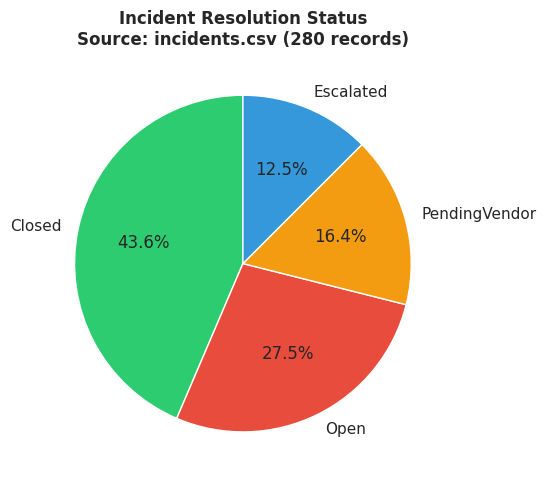

Mean resolution time:   12.0 hours
Median resolution time: 11.5 hours
resolution_status
Closed           122
Open              77
PendingVendor     46
Escalated         35
Name: count, dtype: int64

Unresolved incidents: 158 of 280


In [11]:

res_counts = incidents['resolution_status'].value_counts()

colours = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
plt.figure(figsize=(7, 5))
plt.pie(
    res_counts.values,
    labels=res_counts.index,
    autopct='%1.1f%%',
    colors=colours,
    startangle=90
)
plt.title('Incident Resolution Status\nSource: incidents.csv (280 records)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_incident_resolution.png')
plt.show()

# NumPy statistics on resolved hours
res_hours = np.array(incidents['resolved_hours'].dropna())
print(f"Mean resolution time:   {np.mean(res_hours):.1f} hours")
print(f"Median resolution time: {np.median(res_hours):.1f} hours")

print(res_counts)
print(f"\nUnresolved incidents: "
      f"{incidents[incidents['resolution_status'] != 'Closed'].shape[0]}"
      f" of {len(incidents)}")

 Chart 4: Vehicle type vs incidents

Mean incidents per vehicle type: 70.0
Max: 100 | Min: 47


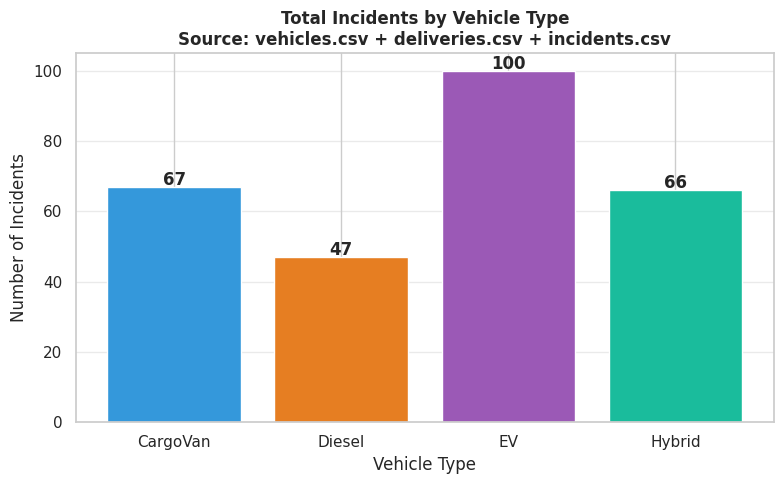

In [12]:
# Join all three files — three-way merge
veh_del_inc = deliveries.merge(
    vehicles[['vehicle_id', 'vehicle_type',
              'maintenance_status', 'battery_health_pct']],
    on='vehicle_id', how='left'
).merge(
    incidents[['delivery_id', 'incident_type']],
    on='delivery_id', how='left'
)

# Count incidents per vehicle type
veh_inc = veh_del_inc.groupby(
    'vehicle_type')['incident_type'].count().reset_index()
veh_inc.columns = ['vehicle_type', 'incident_count']

# Convert to NumPy array for statistics
inc_array = np.array(veh_inc['incident_count'])
print(f"Mean incidents per vehicle type: {np.mean(inc_array):.1f}")
print(f"Max: {np.max(inc_array)} | Min: {np.min(inc_array)}")

plt.figure(figsize=(8, 5))
bars = plt.bar(
    veh_inc['vehicle_type'],
    veh_inc['incident_count'],
    color=['#3498db', '#e67e22', '#9b59b6', '#1abc9c']
)

# plt.text — shows plt.text(x, y, 'label')
for bar, val in zip(bars, veh_inc['incident_count']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(val), ha='center', fontweight='bold'
    )

plt.title('Total Incidents by Vehicle Type\n'
          'Source: vehicles.csv + deliveries.csv + incidents.csv',
          fontsize=12, fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Incidents')
plt.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('chart3_vehicle_incidents.png')
plt.show()

Chart 5: App events API latency

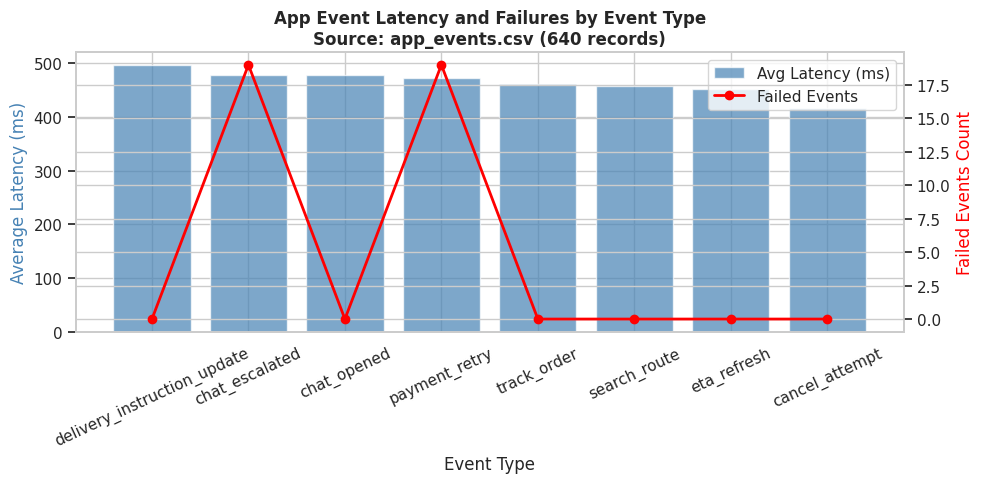

                 event_type  avg_latency  failed_count  total
delivery_instruction_update        496.0             0     75
             chat_escalated        478.0            19     38
                chat_opened        478.0             0     88
              payment_retry        473.0            19     69
                track_order        461.0             0    138
               search_route        457.0             0     99
                eta_refresh        452.0             0    105
             cancel_attempt        417.0             0     28


In [13]:
# lambda function in aggregation
latency = app_events.groupby('event_type').agg(
    avg_latency=('api_latency_ms', 'mean'),
    failed_count=('success_flag', lambda x: (x == 0).sum()),
    total=('event_id', 'count')
).reset_index()
latency['avg_latency'] = latency['avg_latency'].round(0)
latency = latency.sort_values('avg_latency', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars = ax1.bar(latency['event_type'], latency['avg_latency'],
               color='steelblue', alpha=0.7, label='Avg Latency (ms)')
ax2.plot(latency['event_type'], latency['failed_count'],
         color='red', marker='o', linewidth=2, label='Failed Events')

ax1.set_xlabel('Event Type')
ax1.set_ylabel('Average Latency (ms)', color='steelblue')
ax2.set_ylabel('Failed Events Count', color='red')
plt.title('App Event Latency and Failures by Event Type\n'
          'Source: app_events.csv (640 records)',
          fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=25)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('chart4_app_latency.png')
plt.show()

print(latency.to_string(index=False))


Chart 6: Complaints by channel

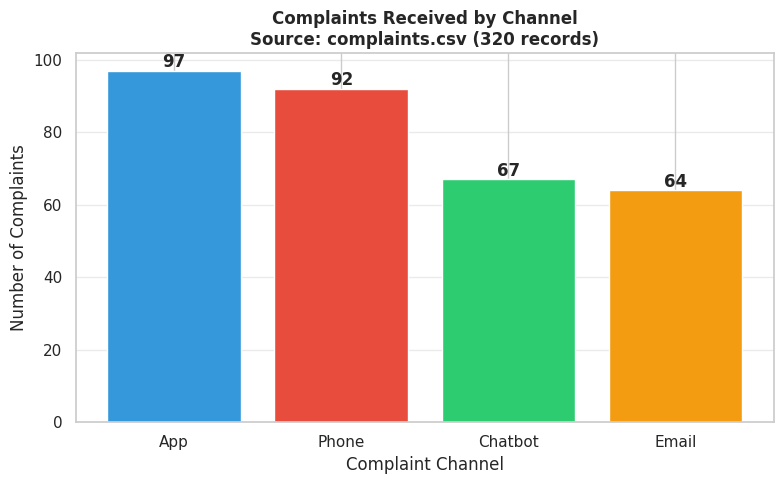


Average resolution days by channel:
channel
App        8.3
Chatbot    7.5
Email      7.6
Phone      8.0
Name: resolution_days, dtype: float64

Fastest channel avg: 7.5 days (Chatbot)
Slowest channel avg: 8.3 days (App)


In [14]:

channel_counts = complaints['channel'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(channel_counts.index, channel_counts.values,
               color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])

plt.title('Complaints Received by Channel\n'
          'Source: complaints.csv (320 records)',
          fontsize=12, fontweight='bold')
plt.xlabel('Complaint Channel')
plt.ylabel('Number of Complaints')
plt.grid(True, axis='y', alpha=0.4)

# plt.text
for i, val in enumerate(channel_counts.values):
    plt.text(i, val + 1, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_complaint_channels.png')
plt.show()

# Average resolution days per channel
print("\nAverage resolution days by channel:")
channel_res = complaints.groupby('channel')['resolution_days'].mean().round(1)
print(channel_res)

# NumPy to find fastest and slowest channel — PDF Section 5
res_array = np.array(channel_res.values)
print(f"\nFastest channel avg: {np.min(res_array)} days "
      f"({channel_res.idxmin()})")
print(f"Slowest channel avg: {np.max(res_array)} days "
      f"({channel_res.idxmax()})")

Chart 7: Order value by customer type

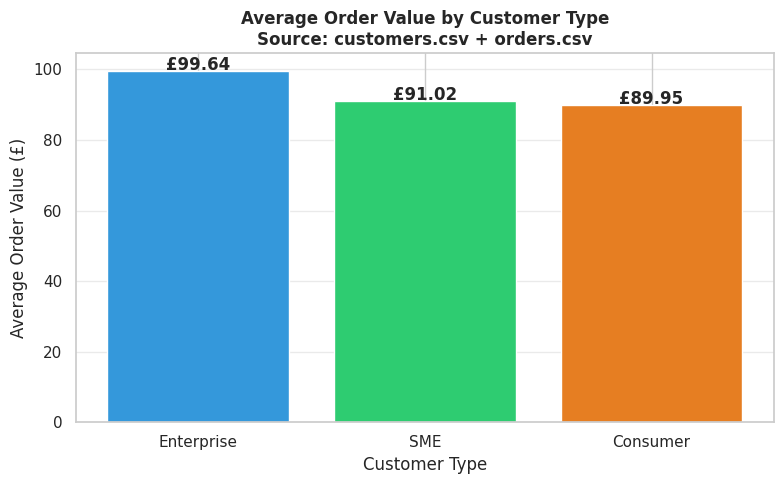

customer_type
Enterprise    99.64
SME           91.02
Consumer      89.95
Name: order_value, dtype: float64

Overall mean order value:   £91.05
Overall median order value: £76.53
Std deviation:              £60.89


In [15]:

cust_orders = orders.merge(
    customers[['customer_id', 'customer_type',
               'loyalty_score', 'home_zone']],
    on='customer_id', how='left'
)

avg_val = cust_orders.groupby(
    'customer_type')['order_value'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    avg_val.index, avg_val.values,
    color=['#3498db', '#2ecc71', '#e67e22']
)

plt.title('Average Order Value by Customer Type\n'
          'Source: customers.csv + orders.csv',
          fontsize=12, fontweight='bold')
plt.xlabel('Customer Type')
plt.ylabel('Average Order Value (£)')
plt.grid(True, axis='y', alpha=0.4)

# plt.text with .format() string format
for bar, val in zip(bars, avg_val.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        "£{:.2f}".format(val),    # .format()
        ha='center', fontweight='bold'
    )

plt.tight_layout()
plt.savefig('chart6_order_value.png')
plt.show()

print(avg_val.round(2))

# NumPy statistics on order values
order_array = np.array(cust_orders['order_value'].dropna())
print(f"\nOverall mean order value:   £{np.mean(order_array):.2f}")
print(f"Overall median order value: £{np.median(order_array):.2f}")
print(f"Std deviation:              £{np.std(order_array):.2f}")


Summary findings across all files

In [16]:

print("=" * 60)
print("NORTHSTAR — KEY FINDINGS ACROSS ALL 9 FILES")
print("=" * 60)

# NumPy statistics on key metrics
fuel_arr   = np.array(deliveries['fuel_or_charge_cost'].dropna())
rating_arr = np.array(deliveries['customer_rating_post_delivery'].dropna())

fail_rate  = round(100 * (deliveries['delivery_status'] == 'Failed').mean(), 1)
delay_rate = round(100 * (deliveries['delivery_status'] == 'Delayed').mean(), 1)
print(f"\ndeliveries.csv:")
print(f"  Failed: {fail_rate}%  |  Delayed: {delay_rate}%")
print(f"  Mean fuel cost:    £{np.mean(fuel_arr):.2f}")
print(f"  Median fuel cost:  £{np.median(fuel_arr):.2f}")
print(f"  Std deviation:     £{np.std(fuel_arr):.2f}")
print(f"  Mean cust rating:  {np.mean(rating_arr):.2f} / 5")

unresolved = (incidents['resolution_status'] != 'Closed').sum()
print(f"\nincidents.csv:")
print(f"  Unresolved: {unresolved} of {len(incidents)}")
print(f"  BatteryAlert: "
      f"{(incidents['incident_type']=='BatteryAlert').sum()}")

in_repair = (vehicles['maintenance_status'] == 'InRepair').sum()
print(f"\nvehicles.csv:")
print(f"  InRepair: {in_repair} of {len(vehicles)} "
      f"({round(100*in_repair/len(vehicles),1)}%)")

app_fail = (app_events['success_flag'] == 0).sum()
print(f"\napp_events.csv:")
print(f"  Failed events: {app_fail} of {len(app_events)} "
      f"({round(100*app_fail/len(app_events),1)}%)")

high_open = complaints[
    (complaints['severity'] == 'High') &
    (complaints['status'] == 'Open')].shape[0]
print(f"\ncomplaints.csv:")
print(f"  Open High-severity: {high_open}")

contract = (drivers['employment_type'] == 'Contract').sum()
print(f"\ndrivers.csv:")
print(f"  Contract drivers: {contract} of {len(drivers)} "
      f"({round(100*contract/len(drivers),1)}%)")

print("\n→ MongoDB integration would connect all 9 files into one view.")

NORTHSTAR — KEY FINDINGS ACROSS ALL 9 FILES

deliveries.csv:
  Failed: 13.9%  |  Delayed: 21.3%
  Mean fuel cost:    £12.84
  Median fuel cost:  £12.64
  Std deviation:     £4.33
  Mean cust rating:  3.87 / 5

incidents.csv:
  Unresolved: 158 of 280
  BatteryAlert: 36

vehicles.csv:
  InRepair: 36 of 120 (30.0%)

app_events.csv:
  Failed events: 38 of 640 (5.9%)

complaints.csv:
  Open High-severity: 14

drivers.csv:
  Contract drivers: 20 of 170 (11.8%)

→ MongoDB integration would connect all 9 files into one view.


Correlation Matrix (deliveries + drivers)

=== CORRELATION MATRIX ===
                               training_score  driver_rating  \
training_score                           1.00          -0.04   
driver_rating                           -0.04           1.00   
years_experience                         0.16           0.08   
manual_route_override_count              0.01          -0.02   
customer_rating_post_delivery            0.00           0.10   
fuel_or_charge_cost                     -0.02          -0.00   
route_distance_km                       -0.07           0.03   

                               years_experience  manual_route_override_count  \
training_score                             0.16                         0.01   
driver_rating                              0.08                        -0.02   
years_experience                           1.00                        -0.02   
manual_route_override_count               -0.02                         1.00   
customer_rating_post_delivery             -0.06             

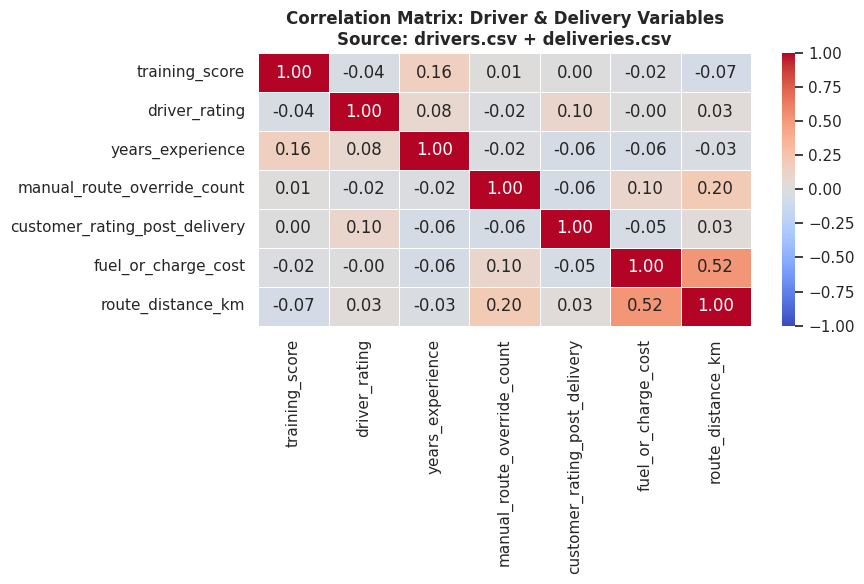

In [17]:
del_drv = deliveries.merge(
    drivers[['driver_id', 'training_score',
             'driver_rating', 'years_experience']],
    on='driver_id', how='left'
)

numeric_data = del_drv[[
    'training_score',
    'driver_rating',
    'years_experience',
    'manual_route_override_count',
    'customer_rating_post_delivery',
    'fuel_or_charge_cost',
    'route_distance_km'
]].dropna()

cor_matrix = numeric_data.corr().round(2)
print("=== CORRELATION MATRIX ===")
print(cor_matrix)

plt.figure(figsize=(9, 6))
sns.heatmap(          # Seaborn
    cor_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Correlation Matrix: Driver & Delivery Variables\n"
          "Source: drivers.csv + deliveries.csv",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_correlation_matrix.png')
plt.show()

Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

del_clean = deliveries[
    deliveries['customer_rating_post_delivery'].notna() &
    deliveries['fuel_or_charge_cost'].notna()
].copy()

# Features (X) and target variable (y)
X = del_clean[['manual_route_override_count',
               'route_distance_km',
               'fuel_or_charge_cost']]
y = del_clean['customer_rating_post_delivery']

# 80% training, 20% testing — standard ML split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("=== LINEAR REGRESSION RESULTS ===")
print(f"R-squared score:                   "
      f"{model.score(X_test, y_test):.4f}")
print(f"manual_route_override coefficient: {model.coef_[0]:.4f}")
print(f"route_distance_km coefficient:     {model.coef_[1]:.4f}")
print(f"fuel_or_charge_cost coefficient:   {model.coef_[2]:.4f}")
print(f"Intercept:                         {model.intercept_:.4f}")

=== LINEAR REGRESSION RESULTS ===
R-squared score:                   -0.0004
manual_route_override coefficient: -0.0548
route_distance_km coefficient:     0.0139
fuel_or_charge_cost coefficient:   -0.0237
Intercept:                         4.0371


 Regression Plot

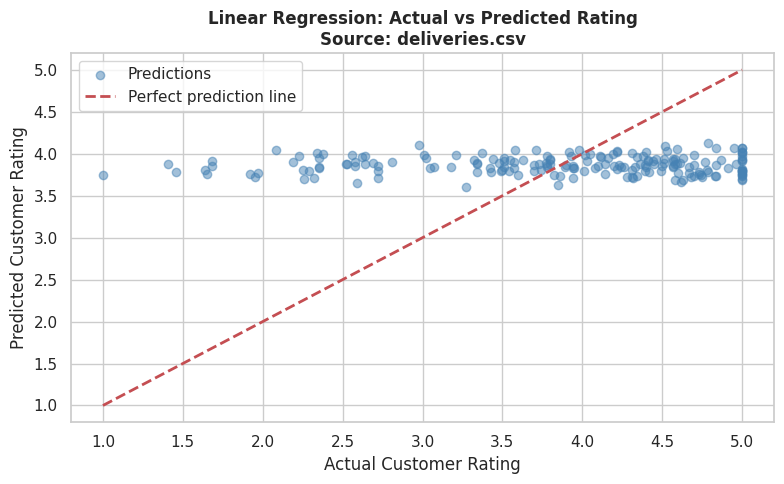

In [20]:
y_pred = model.predict(X_test)

plt.figure(figsize=(8, 5))

# Scatter — exact arguments
plt.scatter(
    y_test, y_pred,
    alpha=0.5,
    color='steelblue',
    marker='o',
    label='Predictions'
)

# Line  exact arguments
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',          #  linestyle='--'
    linewidth=2,    # linewidth argument
    label='Perfect prediction line'
)

# Labels, title, legend, grid — all in PDF Section 7
plt.xlabel('Actual Customer Rating')
plt.ylabel('Predicted Customer Rating')
plt.title('Linear Regression: Actual vs Predicted Rating\n'
          'Source: deliveries.csv',
          fontsize=12, fontweight='bold')
plt.legend()       # plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('chart9_regression_plot.png')
plt.show()